# Switching Performance Probe

Where does the time go in a switched `MultiComponent` run?

This notebook is deliberately minimal. It runs the controlled pendulum **without wall contact**, with
a plant that holds only the **FEM** and **FMU** models, and switches between them through
**switch indicators** so the transition is localized by the hybrid algorithm rather than snapped to
the macro grid.

Mode conditions, on the pendulum angle:

| Condition | Active model |
|---|---|
| `abs(theta) > 10°` | FEM |
| `abs(theta) <= 10°` | FMU |

Dropping contact removes the expensive penalty-contact solve and the `wall_hit` event chain, so what
remains is the cost of the models themselves plus the orchestration around them.

## Setup

In [49]:
from dataclasses import dataclass
from functools import wraps
from pathlib import Path
from time import perf_counter_ns
import sys

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

from plot_setup import FULL_WIDTH, set_professional_style

plt = set_professional_style(latex=True)

from demos.ControlledPendulum.src.master_pendulum.components import FEMPendulum, FMUPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config

from syssimx import Connection, FMUComponent, System
from syssimx.core.multi_comp import Hysteresis, MultiComponent

In [50]:
PLATFORM = sys.platform
DEMO_DIR = _repo / "demos" / "ControlledPendulum"
FMU_DIR = DEMO_DIR / "artifacts" / "fmus" / PLATFORM

fmu_paths = {}
for subdir in FMU_DIR.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {f.stem: f for f in subdir.glob("*.fmu")}
    else:
        fmu_paths[subdir.stem] = subdir

sorted(fmu_paths)

['Actuators', 'Controllers', 'Plants', 'Sensors', 'Trajectories']

## Configuration

`THETA_SWITCH_DEG` is the mode boundary. The setpoint amplitude is 20°, so the pendulum crosses a
10° boundary several times per run — unlike the contact scenario, which produced only two switches.

`DWELL_TIME` matters more here than with a grid-based selector: a localized switch places the state
*exactly* on the boundary, which is where the condition is most likely to fire again.

In [51]:
T0 = 0.0
T_END = 0.4
MACRO_DT = 1e-3
FEM_INTERNAL_DT = 1e-3

THETA_SWITCH_DEG = 10.0
SWITCH_BAND_DEG = 1.0    # hysteresis band around the boundary
DWELL_TIME = 0.01

# Which side of the boundary runs the expensive model.
#   "inner" -> FEM while |theta| <= threshold  (near vertical, max angular rate)
#   "outer" -> FEM while |theta| >  threshold  (max deflection and gravity torque)
# For a 20 deg amplitude the FEM share is 33 % inner versus 67 % outer, so the
# choice dominates the achievable speedup. See "Choosing the region" below.
FEM_REGION = "inner"

FMU_SOLVER = "cvode"
INITIAL_MODE = "FEM" if FEM_REGION == "inner" else "FMU"   # |theta| starts at 0

# Event-collection tolerance, in the indicator's own units (degrees here).
# See the note under "Switch indicators" — the default 1e-6 silently drops
# switches when the indicator is expressed in degrees.
EVENT_TOL_VALUE = 1e-3

# Bisection stops once the interval is this narrow. The default 1e-8 costs
# ~17 model evaluations per switch to resolve a time that nothing needs to
# that precision; 1e-5 is still 1 % of a macro step and costs ~7.
EVENT_TOL_TIME = 1e-5

## Plant: FEM + FMU only

`MasterPendulum` always constructs all three backends, including OpenSim. This probe needs two, so
it uses a local `MultiComponent` with just the FEM and FMU pendulums.

Two pieces of `MasterPendulum` are kept because they are not optional:

- **FEM is initialized first.** It derives mass, inertia, and equivalent length from its mesh, and
  the FMU has to be parameterised from those values or the two models describe different pendulums.
- **`_adapt_state` renames the state.** The FMU takes initial conditions (`theta_start`,
  `omega_start`), while the FEM uses the running state (`theta`, `omega`).

`mode_selector` is deliberately left as `None`, so switching is driven *only* by the indicators.

In [52]:
class SwitchingPendulum(MultiComponent):
    """FEM/FMU pendulum pair with event-localized mode switching."""

    def __init__(self, name="Pendulum", initial_mode=INITIAL_MODE, fmu_solver=FMU_SOLVER):
        self.fem = FEMPendulum(name="FEM_Pendulum")
        self.fmu = FMUPendulum(name="FMU_Pendulum", solver=fmu_solver)

        super().__init__(
            name=name,
            models={"FEM": self.fem, "FMU": self.fmu},
            initial_mode=initial_mode,
            group="Plant",
        )

        self._unify_ports()
        self._initialize_ports_from_specs()
        self.parameters.update({
            "FEM": self.fem.get_parameters(),
            "FMU": self.fmu.get_parameters(),
        })
        self.hysteresis = Hysteresis(dwell_time=DWELL_TIME)

    def _initialize_component(self, t0):
        # FEM first: its mesh determines the physical parameters the FMU needs.
        self.fem.set_parameters(**self.parameters.get("FEM", {}))
        self.fem.initialize(t0)
        self._sync_fmu_from_fem()
        self.fmu.initialize(t0)
        self.direct_feedthrough = self.active_comp.direct_feedthrough

    def _sync_fmu_from_fem(self):
        self.fmu.set_parameters(
            theta_start=np.deg2rad(self.fem.init_params.angular_position_deg),
            omega_start=self.fem.init_params.angular_velocity,
            m=self.fem.mass,
            L=self.fem._equivalent_length,
            J=self.fem.inertia,
            g=9.81 if self.fem._use_gravity else 0.0,
        )

    def _adapt_state(self, state, target_mode):
        if target_mode == "FMU":
            return {
                "theta_start": state["theta"],
                "omega_start": state["omega"],
                "tau": state["tau"],
            }
        return state

In [53]:
def make_fem_parameters():
    init_params = config.InitialConditionParameters()
    init_params.angular_position_deg = 0.0

    sim_params = config.SimulationParameters()
    sim_params.tau = FEM_INTERNAL_DT
    sim_params.t_end = T_END
    sim_params.with_contact = False      # no wall: this is the point of the scenario
    sim_params.use_gravity = True

    anim_params = config.AnimationParameters()
    anim_params.animate = False

    return {"init_params": init_params, "sim_params": sim_params, "anim_params": anim_params}

## Switch indicators

The mode boundary is `THETA_SWITCH_DEG`, applied as a **band** rather than a single value:

$$h_\mathrm{FEM}(\theta) = |\theta| - (\theta_\mathrm{sw} + \Delta),
\qquad
h_\mathrm{FMU}(\theta) = |\theta| - (\theta_\mathrm{sw} - \Delta)$$

FEM takes over on a **rising** crossing of the upper edge; FMU takes back over on a **falling**
crossing of the lower edge. This is an ordinary Schmitt trigger, and it is also **required** here —
see the note below.

The indicator is evaluated against the **wrapper**, so it reads the unified `theta` output and works
regardless of which sub-model is active. Port values are Pint quantities, hence the unwrap.

> **The event tolerance must match the indicator's units.** After bisection localizes a crossing,
> `HybridAlgorithm._collect_events_at_time` only accepts an event if `abs(indicator) <=
> algorithm.tol_value`, whose default is `1e-6`. This indicator is in **degrees** and moves at
> roughly 300 °/s, so bisecting to `tol_time = 1e-8` leaves it around `3e-6` — just above the gate.
> The switch is then located but never dispatched.
>
> Measured on a 20° sine over this horizon, which crosses ±10° four times:
>
> | `tol_value` | switches detected |
> |---|---|
> | `1e-6` (default) | **2 of 4** |
> | `1e-3` | 4 of 4 |
>
> Two of four is the dangerous case: it looks like it works. `EVENT_TOL_VALUE` is set below to a
> degree-appropriate value. If you rewrite the indicator in radians or normalise it, scale this
> accordingly.

> **Why the band is required, not merely good practice.** If both indicators share one threshold,
> they are zero at the *same* instant. `_collect_events_at_time` accepts any indicator near zero
> without consulting its direction, so both switch events are dispatched together. The hybrid
> algorithm then sees two events on one component and runs
> `_verify_event_commutativity_dynamically`, which snapshots the component, replays each ordering,
> and restores between them. But handling a switch event *changes which sub-model is active*, so the
> second restore pushes an FMU snapshot into the FEM model and fails with
> `Incompatible snapshot mode`.
>
> Measured on the same 20° sine:
>
> | Band | Instants with two simultaneous switch events | Result |
> |---|---|---|
> | `0.0` | 1 | `ValueError: Incompatible snapshot mode` |
> | `0.5` | 0 | 4 switches, correctly alternating |
>
> Separating the thresholds makes the two zeros distinct, so the situation cannot arise. Two
> mutually exclusive mode requests at the same instant is a modelling error in any case — order
> would decide the outcome.

In [54]:
def theta_deg(comp):
    """Wrapper angle in degrees, unwrapping the Pint quantity."""
    value = comp.outputs["theta"].get()
    if value is None:
        return 0.0
    return float(np.rad2deg(getattr(value, "magnitude", value)))


UPPER_EDGE_DEG = THETA_SWITCH_DEG + SWITCH_BAND_DEG
LOWER_EDGE_DEG = THETA_SWITCH_DEG - SWITCH_BAND_DEG

if FEM_REGION == "outer":
    FEM_EDGE_DEG, FEM_DIR = UPPER_EDGE_DEG, +1    # enter FEM rising past the upper edge
    FMU_EDGE_DEG, FMU_DIR = LOWER_EDGE_DEG, -1
else:
    FEM_EDGE_DEG, FEM_DIR = LOWER_EDGE_DEG, -1    # enter FEM falling past the lower edge
    FMU_EDGE_DEG, FMU_DIR = UPPER_EDGE_DEG, +1


def enter_fem(comp):
    """Crosses zero on the edge where FEM takes over."""
    return abs(theta_deg(comp)) - FEM_EDGE_DEG


def enter_fmu(comp):
    """Crosses zero on the edge where FMU takes over."""
    return abs(theta_deg(comp)) - FMU_EDGE_DEG


plant = SwitchingPendulum(name="Pendulum")

# Registered before initialization, as add_switch_indicator requires. The two
# thresholds differ so the indicators are never zero at the same instant.
plant.add_switch_indicator("to_fem", enter_fem, target_mode="FEM", direction=FEM_DIR)
plant.add_switch_indicator("to_fmu", enter_fmu, target_mode="FMU", direction=FMU_DIR)

plant.set_parameters(**{"FEM": make_fem_parameters()})

# The FEM plant must not be perturbed before its torque boundary is assembled,
# so the feedthrough map is declared rather than detected.
plant.direct_feedthrough = {"theta": set(), "omega": set(), "alpha": {"tau"}}

plant._switch_targets

{'to_fem': 'FEM', 'to_fmu': 'FMU'}

## System

The closed loop without the contact branch: setpoint, PID, drive, plant, and the sensor chain.
No event connections are needed — there is no `wall_hit`, and the switch events are handled by the
wrapper itself.

In [55]:
setpoint = FMUComponent(
    name="Setpoint", fmu_path=fmu_paths["Trajectories"]["SetPoint"], group="Reference"
)
pid = FMUComponent(
    name="PID", fmu_path=fmu_paths["Controllers"]["PIDControllerReset_euler"], group="Controller"
)
drive = FMUComponent(
    name="Drive", fmu_path=fmu_paths["Actuators"]["DriveDynamic"], group="Actuator"
)
angle_sensor = FMUComponent(
    name="Angle Sensor", fmu_path=fmu_paths["Sensors"]["AngleSensor"], group="Sensors"
)
angle_decoder = FMUComponent(
    name="Angle Decoder", fmu_path=fmu_paths["Sensors"]["AngleDecoder"], group="Signal Processing"
)

system = System(name="Switching Performance")
for comp in (setpoint, pid, drive, plant, angle_sensor, angle_decoder):
    system.add_component(comp)

for conn in [
    Connection("Setpoint", "theta_ref", "PID", "theta_ref"),
    Connection("Pendulum", "theta", "Angle Sensor", "theta"),
    Connection("Angle Sensor", "v_out", "Angle Decoder", "v_in"),
    Connection("Angle Decoder", "theta", "PID", "theta_meas"),
    Connection("PID", "u", "Drive", "u_control"),
    Connection("Drive", "torque", "Pendulum", "tau"),
    Connection("Pendulum", "omega", "Drive", "omega"),
]:
    system.add_connection(conn)

system.initialize(t0=T0)

# The plant has switch indicators, so it is an event source and the hybrid
# algorithm is selected automatically. Tolerances are set after initialize()
# because that is when the algorithm instance exists.
system.algorithm.tol_value = EVENT_TOL_VALUE
system.algorithm.tol_time = EVENT_TOL_TIME

type(system.algorithm).__name__, [c.name for c in system.event_sources]

('HybridAlgorithm', ['Pendulum'])

## Instrumentation and run

Only the model step is timed. `_do_step_internal` is wrapped rather than `do_step` because the
hybrid algorithm calls it directly for trial steps, bisection iterations, and the post-localization
re-step; wrapping `do_step` would miss all of those.

Whatever is left over — `run_s` minus the two model totals — is orchestration.

In [56]:
@dataclass
class ModelTimer:
    label: str
    wall_ns: int = 0
    n_calls: int = 0

    @property
    def wall_s(self):
        return self.wall_ns * 1e-9


def instrument(comp, label):
    timer = ModelTimer(label=label)
    original = comp._do_step_internal

    @wraps(original)
    def timed(t, dt, *args, **kwargs):
        start = perf_counter_ns()
        try:
            return original(t, dt, *args, **kwargs)
        finally:
            timer.wall_ns += perf_counter_ns() - start
            timer.n_calls += 1

    comp._do_step_internal = timed
    return timer


timers = {"FEM": instrument(plant.fem, "FEM"), "FMU": instrument(plant.fmu, "FMU")}

In [57]:
sim_time = T_END - T0

with tqdm(total=sim_time, desc="switched run", unit=" sim s") as bar:
    progressed = 0.0

    def on_progress(t, _tf):
        global progressed
        now = min(max(t - T0, 0.0), sim_time)
        bar.update(now - progressed)
        progressed = now

    run_start = perf_counter_ns()
    system.run(T0, T_END, MACRO_DT, progress=on_progress)
    run_s = (perf_counter_ns() - run_start) * 1e-9

print(f"run: {run_s:.1f} s | switches: {len(plant.sync_events)}")

switched run:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

run: 42.9 s | switches: 1


## Where the time went

In [58]:
fem_s, fmu_s = timers["FEM"].wall_s, timers["FMU"].wall_s
unaccounted_s = run_s - fem_s - fmu_s
model_calls = timers["FEM"].n_calls + timers["FMU"].n_calls

breakdown = pd.DataFrame(
    [
        {"part": "FEM steps", "wall_s": fem_s, "calls": timers["FEM"].n_calls},
        {"part": "FMU steps", "wall_s": fmu_s, "calls": timers["FMU"].n_calls},
        {"part": "orchestration", "wall_s": unaccounted_s, "calls": model_calls},
    ]
)
breakdown["share"] = breakdown["wall_s"] / run_s
breakdown["ms_per_call"] = 1e3 * breakdown["wall_s"] / breakdown["calls"].clip(lower=1)

breakdown.style.format({"wall_s": "{:.2f}", "calls": "{:.0f}", "share": "{:.1%}",
                        "ms_per_call": "{:.2f}"}).hide(axis="index")

part,wall_s,calls,share,ms_per_call
FEM steps,38.50,435,89.9%,88.52
FMU steps,0.02,420,0.1%,0.05
orchestration,4.33,855,10.1%,5.06


## Mode timeline

`sync_events` records every completed switch. Because the switch is an event, each entry sits on the
located crossing of `|theta| = 10°` rather than on a macro-step boundary.

In [59]:
def mode_intervals(sync_events, initial_mode, t0, t_end):
    rows, mode, left = [], initial_mode, t0
    for event in sync_events:
        right = float(event["time"])
        rows.append((left, right, mode))
        mode, left = event["to_mode"], right
    rows.append((left, t_end, mode))
    return rows


intervals = mode_intervals(plant.sync_events, INITIAL_MODE, T0, T_END)
active_time = {"FEM": 0.0, "FMU": 0.0}
for left, right, mode in intervals:
    active_time[mode] += max(0.0, right - left)

pd.DataFrame(
    [{"mode": m, "sim_s": s, "share": s / sim_time} for m, s in active_time.items()]
).style.format({"sim_s": "{:.3f}", "share": "{:.1%}"}).hide(axis="index")

mode,sim_s,share
FEM,0.201,50.3%
FMU,0.199,49.7%


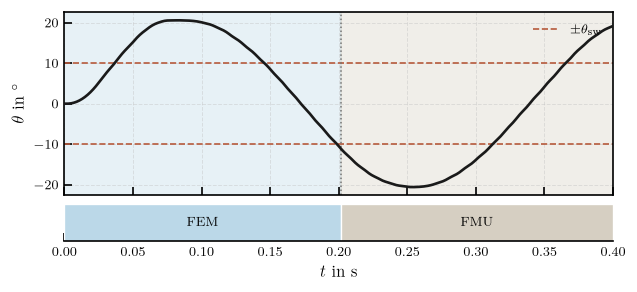

In [60]:
t_hist, data = system.get_history()["Pendulum"]
t_arr = np.asarray(t_hist, dtype=float)
theta_deg_arr = np.rad2deg(np.asarray(data["theta"], dtype=float))

MODE_COLORS = {"FEM": "#bbd8e8", "FMU": "#d6cfc2"}

fig, (ax, ax_mode) = plt.subplots(
    2, 1, figsize=(FULL_WIDTH, 0.42 * FULL_WIDTH),
    height_ratios=[5, 1], sharex=True, gridspec_kw={"hspace": 0.08},
)

for left, right, mode in intervals:
    ax.axvspan(left, right, color=MODE_COLORS[mode], alpha=0.35, zorder=0)

ax.plot(t_arr, theta_deg_arr, color="#1a1a1a", lw=1.6, zorder=3)
for sign in (+1, -1):
    ax.axhline(sign * THETA_SWITCH_DEG, color="#B65A3C", ls="--", lw=1.0,
               label=r"$\pm\theta_\mathrm{sw}$" if sign > 0 else None)
for event in plant.sync_events:
    ax.axvline(float(event["time"]), color="0.45", ls=":", lw=0.9, zorder=2)

ax.set_ylabel(r"$\theta$ in $^\circ$")
ax.grid(True, alpha=0.4)
ax.legend(loc="upper right", fontsize=8, frameon=False)

for left, right, mode in intervals:
    width = right - left
    ax_mode.broken_barh([(left, width)], (0, 1), facecolors=MODE_COLORS[mode],
                        edgecolors="white", linewidth=0.8)
    if width / sim_time > 0.06:
        ax_mode.text(left + width / 2, 0.5, mode, ha="center", va="center", fontsize=8)

ax_mode.set_ylim(0, 1)
ax_mode.set_yticks([])
ax_mode.set_xlim(T0, T_END)
ax_mode.set_xlabel(r"$t$ in s")
for spine in ("left", "right", "top"):
    ax_mode.spines[spine].set_visible(False)

plt.show()

## Choosing the region

For a sinusoidal setpoint of amplitude $A$, the share of the horizon spent outside a threshold
$\theta_\mathrm{sw}$ is

$$P(|\theta| > \theta_\mathrm{sw}) = \frac{2}{\pi}\arccos\!\left(\frac{\theta_\mathrm{sw}}{A}\right)$$

which at $A = 20°$ and $\theta_\mathrm{sw} = 10°$ gives **66.7 %**. Putting FEM there means the
expensive model runs two-thirds of the time, and no orchestration tuning can recover that.

| Rule | FEM share | est. run | vs. all-FEM |
|---|---|---|---|
| `outer`, 10° | 66.7 % | 52.5 s | 1.29x |
| `outer`, 15° | 46.0 % | 38.5 s | 1.76x |
| **`inner`, 10°** | **33.3 %** | **29.9 s** | **2.27x** |
| `inner`, 8° | 26.2 % | 25.0 s | 2.71x |

`inner` is the default here. It is also physically reasonable: near vertical the pendulum is at
maximum angular rate, so centrifugal loading and the resulting deflection peak there. `outer` is
equally defensible on gravity-torque and bending grounds — set `FEM_REGION` to whichever the
physics argument supports, knowing what it costs.

## Reading the result

The `orchestration` row is small in this scenario, roughly 6 ms per model call against 88 ms in the
contact benchmark. The wrapper is not the bottleneck. **The waste is inside the FEM total**, and the
call count exposes it.

With FEM active for a fraction $f$ of the horizon, the accepted work is $f \cdot T/\Delta t$ steps.
Compare that with `timers["FEM"].n_calls`. In a measured run with $f = 0.64$ the accepted count was
257 while the FEM was called 589 times:

| | calls | time | |
|---|---|---|---|
| accepted | 257 | 21.8 s | the actual solution |
| trial | 257 | 21.8 s | stepped, then rolled back |
| bisection | 85 | 7.2 s | 5 switches x 17 iterations |

**Roughly 57 % of FEM time was discarded.** Two separate causes:

1. **Trial steps.** `_detect_crossings` advances every event source across the macro step, evaluates
   the indicators, and restores the snapshot. If no crossing is found, Gauss-Seidel then steps the
   same interval again. On an event-free macro step the model is solved twice for one result.
2. **Bisection.** Each located event costs $\log_2(\Delta t / \mathtt{tol\_time})$ further
   evaluations. `EVENT_TOL_TIME` above trades placement precision against that count.

For a component that already resolves its own events internally — such as `FEMPendulum` with
contact, which reduces its sub-step near the wall and calls `report_internal_event` — bisection is
avoidable entirely. `_locate_event_time` accepts the reported interval directly when it is already
narrower than `tol_time`. That shortcut only fires if `tol_time` is at least as coarse as the
component's internal sub-step.

To attribute the remaining orchestration cost, profile rather than adding more manual timers:

```python
import cProfile, pstats
cProfile.run("system.run(T0, T_END, MACRO_DT)", "perf.prof")
pstats.Stats("perf.prof").sort_stats("cumulative").print_stats(25)
```

Absolute timings move with interpreter and machine state; compare only within one environment.